In [3]:
## Modified original code to support two datasets instead of one.
## Added the original subject names to the flow for tracking purposes.

In [4]:
from pathlib import Path
from pandas import read_pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

story = 'El_espejo'
measures_path_1 = Path('results_og_all_El_espejo filtered', 'measures')
measures_path_2 = Path('results_og_all_El_espejo filtered', 'measures')
measures_correlation_path = Path('results_og_all_El_espejo filtered', 'measures_correlation')
items_1 = list(measures_path_1.iterdir())
items_2 = list(measures_path_2.iterdir())
item_subj_1 = {item.name: list(item.iterdir()) for item in items_1}
item_subj_2 = {item.name: list(item.iterdir()) for item in items_2}
common_items = set(item_subj_1.keys()) & set(item_subj_2.keys())
measures = ['FFD', 'FPRT', 'TFD', 'SFD', 'SPRT', 'RRT']
n_bins = 10

In [5]:
def binarize_measure(subj, measure):
    measure_mask = subj[measure] > 0
    subj = subj.astype({measure: np.float32})
    subj.loc[:, measure] = pd.qcut(subj[measure][measure_mask], n_bins, labels=False,
                                   duplicates='drop')
    subj.loc[:, measure] = subj[measure].fillna(0)
    subj.loc[:, measure] = subj[measure].astype(np.int32)

def binarize_subjects_measures(subjects, measures):
    binarized_subjects = []
    for name, subj in subjects:
        subj = subj[~subj['excluded']]
        for measure in measures:
            binarize_measure(subj, measure)
        binarized_subjects.append((name, subj))
    return binarized_subjects

def compute_correlation_matrices(subjects_1, subjects_2, all_measures):
    correlation_matrices = []

    for measure in all_measures:
        correlation_matrix = np.zeros((len(subjects_1), len(subjects_2)))
        for i, (name1, subj1) in enumerate(subjects_1):
            for j, (name2, subj2) in enumerate(subjects_2):
                corr = spearmanr(subj1[measure], subj2[measure])[0]
                correlation_matrix[i, j] = 0 if np.isnan(corr) else corr
        correlation_matrices.append(correlation_matrix)

    return correlation_matrices

def plot_correlation_matrices(correlation_matrices, all_measures, title, min_val=0.0, max_val=1.0, filename='global_avg'): 
    fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    
    for i, measure in enumerate(all_measures):
        sns.heatmap(correlation_matrices[i], ax=axes[i // 3, i % 3], cmap='coolwarm', center=0,
                    vmin=min_val, vmax=max_val, cbar=(i == 0), cbar_ax=cbar_ax if i == 0 else None)
        axes[i // 3, i % 3].set_title(measure)
        axes[i // 3, i % 3].tick_params(axis='y', rotation=0)
        axes[i // 3, i % 3].tick_params(axis='x', rotation=0)
    
    if title:
        fig.suptitle(title + f' - {n_bins} bins')
    plt.subplots_adjust(right=0.9)
    measures_correlation_path.mkdir(parents=True, exist_ok=True)
    fig.savefig(measures_correlation_path / f'{filename}.png', dpi=300)

In [6]:
items_correlation_matrices = {}
items_subject_names = {}
for item in common_items:
    subjects_1 = [(subj_path.stem, read_pickle(subj_path)) for subj_path in item_subj_1[item]]
    subjects_2 = [(subj_path.stem, read_pickle(subj_path)) for subj_path in item_subj_2[item]]
    binarized_subjects_1 = binarize_subjects_measures(subjects_1, measures)
    binarized_subjects_2 = binarize_subjects_measures(subjects_2, measures)
    correlation_matrices = compute_correlation_matrices(binarized_subjects_1, binarized_subjects_2, measures)
    items_correlation_matrices[item] = correlation_matrices
    items_subject_names[item] = {
        "subjects_1": [name for name, _ in binarized_subjects_1],
        "subjects_2": [name for name, _ in binarized_subjects_2],
    }

In [7]:
rows = []

for item in items_correlation_matrices:
    correlation_matrices = items_correlation_matrices[item]

    subj_names_1 = items_subject_names[item]["subjects_1"]
    subj_names_2 = items_subject_names[item]["subjects_2"]

    for m_idx, measure in enumerate(measures):
        mat = correlation_matrices[m_idx]

        for i, name1 in enumerate(subj_names_1):
            for j, name2 in enumerate(subj_names_2):
                rows.append({
                    "item": item,
                    "subject_1": name1,
                    "subject_2": name2,
                    "measure": measure,
                    "correlation": mat[i, j]
                })

df = pd.DataFrame(rows)

In [8]:
df[df['measure'] == 'FFD'].sort_values(by=['correlation'], ascending=False)

,item,subject_1,subject_2,measure,correlation
1520,El espejo,sub-068,sub-068,FFD,1.000000
1440,El espejo,sub-098,sub-098,FFD,1.000000
1400,El espejo,sub-107,sub-107,FFD,1.000000
1280,El espejo,sub-006,sub-006,FFD,1.000000
1360,El espejo,sub-042,sub-042,FFD,1.000000
...,...,...,...,...,...
484,El espejo,sub-088,sub-024,FFD,-0.003962
653,El espejo,sub-024,sub-021,FFD,-0.004718
1147,El espejo,sub-021,sub-024,FFD,-0.004718
488,El espejo,sub-088,sub-048,FFD,-0.047310


In [9]:
def compute_mean_correlations(correlation_matrices, measures, subject_names):
    mean_corr_df = pd.DataFrame(index=subject_names)

    for corr_matrix, measure in zip(correlation_matrices, measures):
        mat = pd.DataFrame(corr_matrix, index=subject_names, columns=subject_names)

        np.fill_diagonal(mat.values, np.nan)

        mean_corr_df[measure] = mat.mean(axis=1)

    return mean_corr_df

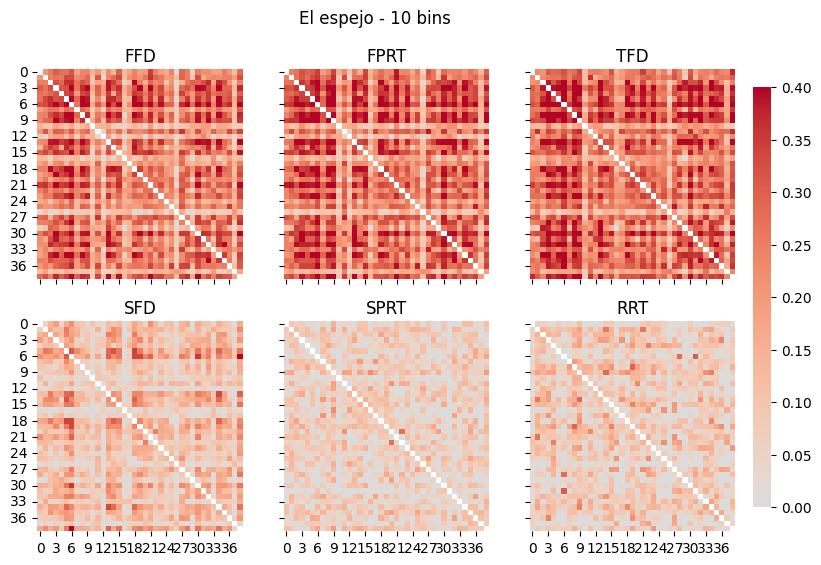

In [10]:
all_items_mean_corr = {}

for item in items_correlation_matrices:
    
    correlation_matrices = items_correlation_matrices[item]

    mean_corr_df = compute_mean_correlations(correlation_matrices, measures, subj_names_1)

    all_items_mean_corr[item] = mean_corr_df
    
    plot_correlation_matrices(
        correlation_matrices,
        measures,
        title=item,
        min_val=0.0,
        max_val=0.4,
        filename=f"{item}"
    )

In [11]:
all_items_mean_corr
import pickle

with open(f"all_items_mean_corr_{story}.pkl", "wb") as f:
    pickle.dump(all_items_mean_corr, f)

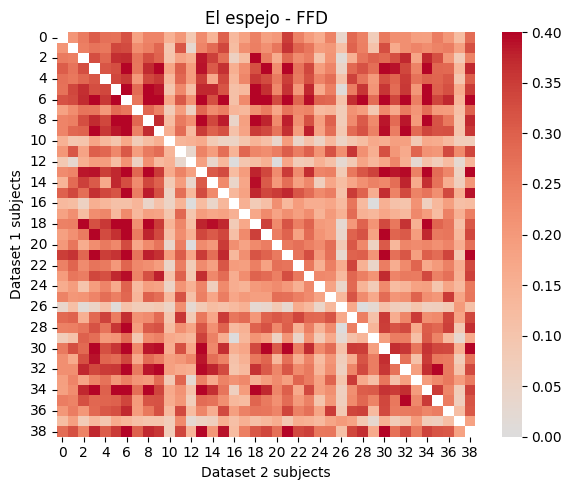

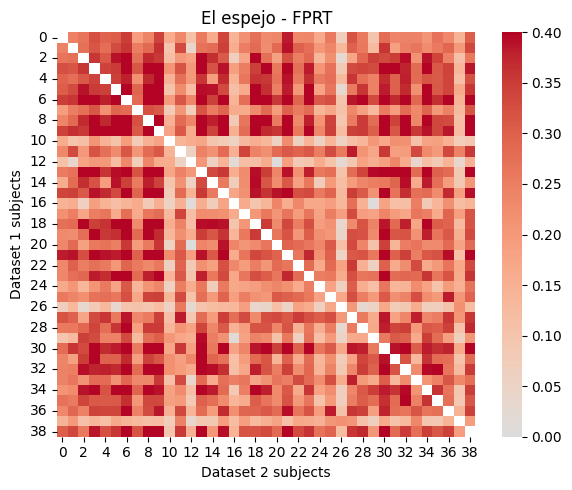

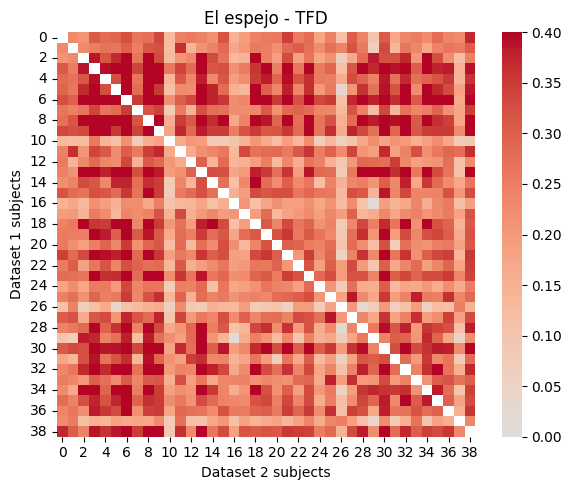

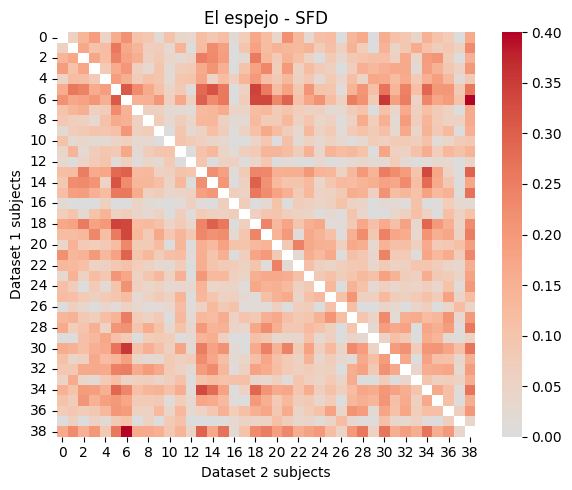

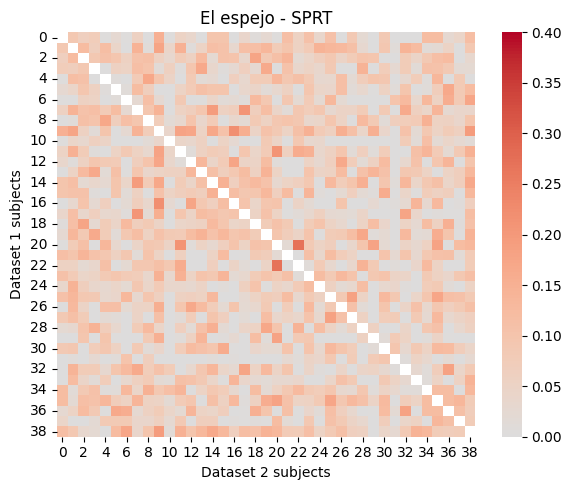

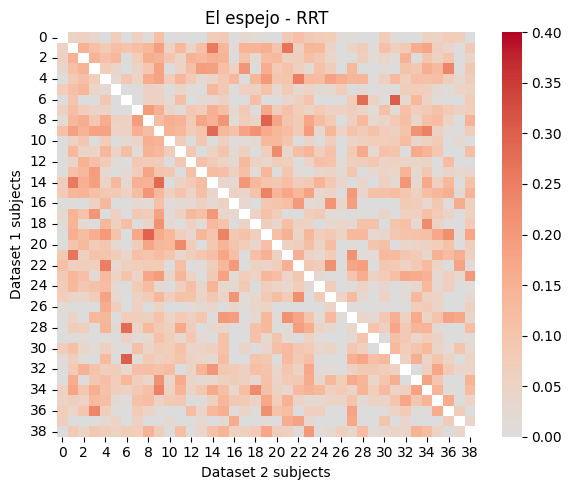

In [12]:
def plot_individual_correlation_matrices(correlation_matrices, all_measures, title=None,
                                         min_val=0.0, max_val=1.0, filename_prefix='plot'):
    measures_correlation_path.mkdir(parents=True, exist_ok=True)

    for i, measure in enumerate(all_measures):
        fig, ax = plt.subplots(figsize=(6, 5))

        sns.heatmap(
            correlation_matrices[i],
            ax=ax,
            cmap='coolwarm',
            center=0,
            vmin=min_val,
            vmax=max_val,
            cbar=True
        )

        ax.set_title(measure if title is None else f'{title} - {measure}')
        ax.tick_params(axis='y', rotation=0)
        ax.tick_params(axis='x', rotation=0)
        ax.set_xlabel('Dataset 2 subjects')
        ax.set_ylabel('Dataset 1 subjects')

        plt.tight_layout()

        safe_measure = measure.replace(" ", "_").replace("/", "_")
        safe_prefix = filename_prefix.replace(" ", "_").replace("/", "_")

        fig.savefig(
            measures_correlation_path / f'{safe_prefix}_{safe_measure}.png',
            dpi=300
        )

        plt.show()
        plt.close(fig)
        
for item in items_correlation_matrices:
    correlation_matrices = items_correlation_matrices[item]
    safe_item = item.replace(" ", "_").replace("/", "_")

    plot_individual_correlation_matrices(
        correlation_matrices,
        measures,
        title=item,
        min_val=0.0,
        max_val=0.4,
        filename_prefix=safe_item
    )

In [13]:
mapping_rows = []

for item in items_subject_names:
    for i, name in enumerate(items_subject_names[item]["subjects_1"]):
        mapping_rows.append({
            "item": item,
            "dataset": "dataset_1",
            "index": i,
            "subject_name": name
        })

    for j, name in enumerate(items_subject_names[item]["subjects_2"]):
        mapping_rows.append({
            "item": item,
            "dataset": "dataset_2",
            "index": j,
            "subject_name": name
        })

mapping_df = pd.DataFrame(mapping_rows)

In [14]:
mapping_df

,item,dataset,index,subject_name
0,El espejo,dataset_1,0,sub-067
1,El espejo,dataset_1,1,sub-078
2,El espejo,dataset_1,2,sub-046
3,El espejo,dataset_1,3,sub-079
4,El espejo,dataset_1,4,sub-028
...,...,...,...,...
73,El espejo,dataset_2,34,sub-042
74,El espejo,dataset_2,35,sub-107
75,El espejo,dataset_2,36,sub-098
76,El espejo,dataset_2,37,sub-086


In [15]:
corr = pd.read_csv('normal.csv')
corr_new = pd.read_csv('normal_nuevo.csv')
corr_new = corr_new[corr_new['correlation'] < 1]
corr_new = corr_new[['subject_1', 'subject_2', 'measure', 'correlation']]
print(corr_new.shape)
print(corr.shape)
merged_df = pd.merge(corr, corr_new, left_on=['subject_1', 'subject_2', 'measure'], right_on=['subject_1', 'subject_2', 'measure'], suffixes=('_corr', '_corr_new'))
merged_df = merged_df[['subject_1', 'subject_2', 'measure', 'correlation_corr', 'correlation_corr_new']]
merged_df

(18520, 4)
(9240, 4)


,subject_1,subject_2,measure,correlation_corr,correlation_corr_new
0,sub-067,sub-054,FFD,0.230163,0.230163
1,sub-067,sub-078,FFD,0.206412,0.206412
2,sub-067,sub-046,FFD,0.255660,0.255660
3,sub-067,sub-097,FFD,0.252057,0.252057
4,sub-067,sub-079,FFD,0.303572,0.303572
...,...,...,...,...,...
9235,sub-098,sub-013,RRT,-0.044551,-0.044551
9236,sub-098,sub-068,RRT,-0.038782,-0.038782
9237,sub-086,sub-013,RRT,-0.121456,-0.121456
9238,sub-086,sub-068,RRT,0.038757,0.038757


In [16]:
are_equal = np.isclose(
    merged_df['correlation_corr'],
    merged_df['correlation_corr_new']
).all()

print('all rows equal:', are_equal)

if not are_equal:
    mismatches = merged_df.loc[
        ~np.isclose(
            merged_df['correlation_corr'],
            merged_df['correlation_corr_new']
        )
    ]
    print('mismatch count:', len(mismatches))
    mismatches.head()

all rows equal: True
